In [6]:
import pandas as pd

# File paths
train_path = r"C:\Users\parna\Downloads\archive (4)\twitter_training.csv"
val_path = r"C:\Users\parna\Downloads\archive (4)\twitter_validation.csv"

# Load datasets
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)

# Quick check
print(train_df.head())
print(val_df.head())




   2401  Borderlands  Positive  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

  im getting on borderlands and i will murder you all ,  
0  I am coming to the borders and I will kill you...     
1  im getting on borderlands and i will kill you ...     
2  im coming on borderlands and i will murder you...     
3  im getting on borderlands 2 and i will murder ...     
4  im getting into borderlands and i can murder y...     
   3364   Facebook Irrelevant  \
0   352     Amazon    Neutral   
1  8312  Microsoft   Negative   
2  4371      CS-GO   Negative   
3  4433     Google    Neutral   
4  6273       FIFA   Negative   

  I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣  
0

In [7]:
print(train_df.info())
print(val_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 4 columns):
 #   Column                                                                                                                                                                                                                                

In [8]:
# Check column names
print(train_df.columns)

# Check few rows
train_df.head()


Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')


,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [13]:
train_df.columns = ['tweet_id', 'entity', 'sentiment', 'tweet_text']
val_df.columns = ['tweet_id', 'entity', 'sentiment', 'tweet_text']


In [14]:
train_df.isnull().sum()


tweet_id        0
entity          0
sentiment       0
tweet_text    686
dtype: int64

In [15]:
train_df = train_df.dropna(subset=['tweet_text'])


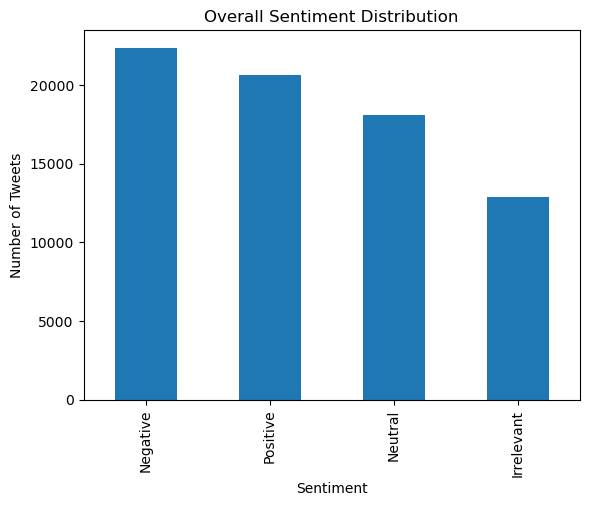

In [16]:
import matplotlib.pyplot as plt

train_df['sentiment'].value_counts().plot(kind='bar')
plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()


In [17]:
entity_sentiment = (
    train_df
    .groupby(['entity', 'sentiment'])
    .size()
    .unstack(fill_value=0)
)

entity_sentiment.head()


sentiment,Irrelevant,Negative,Neutral,Positive
entity,,,,
Amazon,186,575,1207,308
ApexLegends,192,591,936,634
AssassinsCreed,264,375,156,1439
Battlefield,915,464,351,586
Borderlands,240,426,597,1016


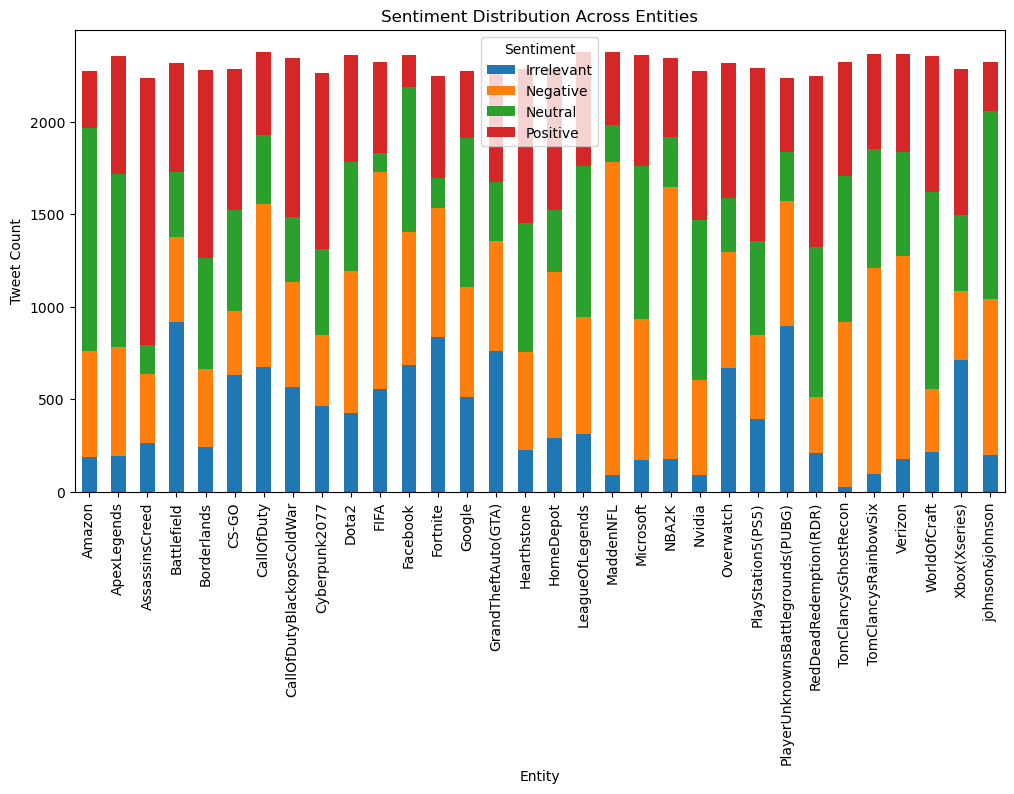

In [18]:
entity_sentiment.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Sentiment Distribution Across Entities")
plt.xlabel("Entity")
plt.ylabel("Tweet Count")
plt.legend(title="Sentiment")
plt.show()


In [20]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

train_df.loc[:, 'clean_tweet'] = train_df['tweet_text'].apply(clean_text)


In [21]:
train_df.head()


,tweet_id,entity,sentiment,tweet_text,clean_tweet
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder y...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...,im getting into borderlands and i can murder y...


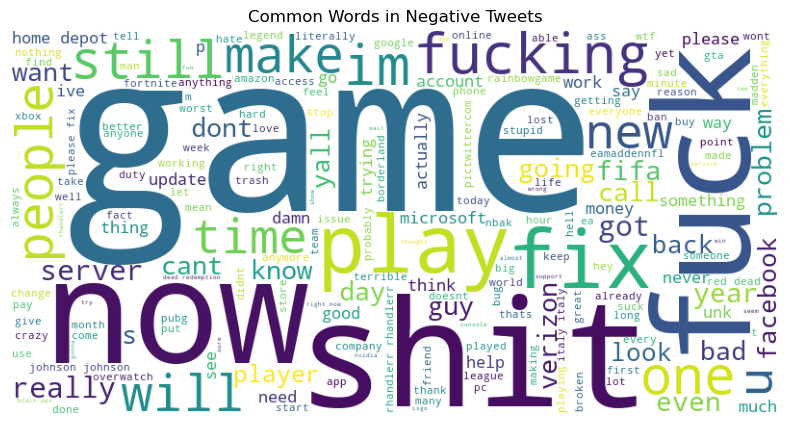

In [22]:
from wordcloud import WordCloud

neg_text = " ".join(
    train_df[train_df['sentiment'] == 'Negative']['clean_tweet']
)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(neg_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Common Words in Negative Tweets")
plt.show()


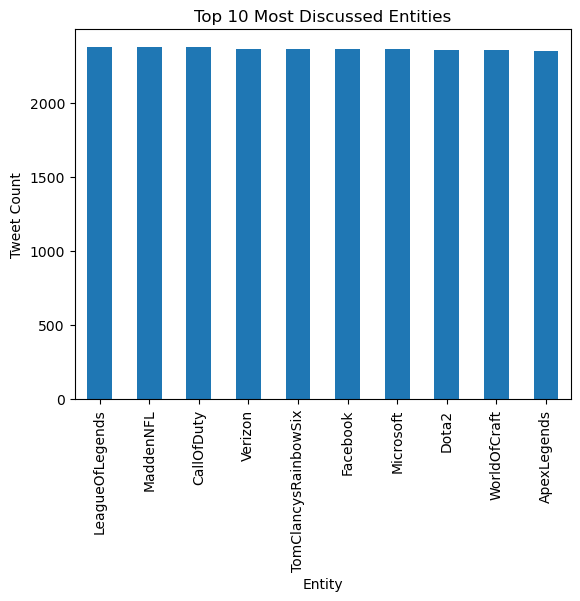

In [23]:
top_entities = train_df['entity'].value_counts().head(10)

top_entities.plot(kind='bar')
plt.title("Top 10 Most Discussed Entities")
plt.xlabel("Entity")
plt.ylabel("Tweet Count")
plt.show()
